## BÀI TẬP THỰC HÀNH CHƯƠNG 2 (PHẦN 2)
**Mục II.1: Thực hiện thuật toán Canny bằng các thư viện**

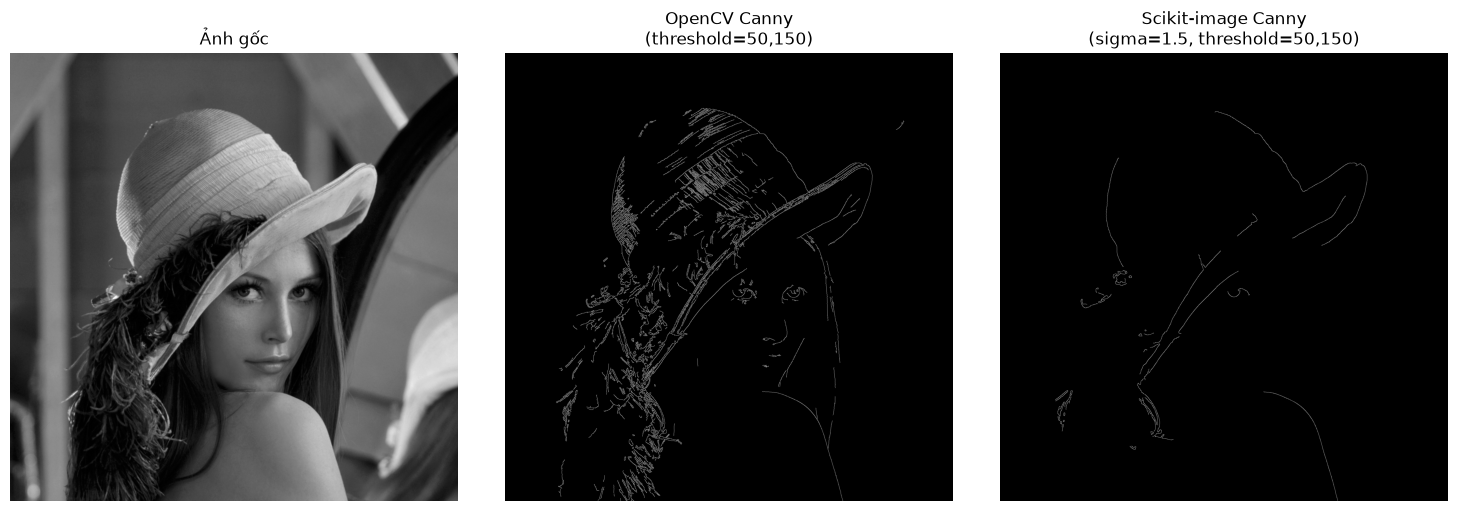

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage.feature

# Đọc ảnh xám (dùng ảnh có sẵn trong datatest/, đồng bộ với các bài trước)
img_path = 'datatest/test.jpg'
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError(f"Không đọc được ảnh tại path: {img_path}")

# Tham số chung
low_threshold, high_threshold = 50, 150
sigma = 1.5

# 1. Phát hiện cạnh bằng OpenCV Canny
edges_cv = cv2.Canny(image, low_threshold, high_threshold)

# 2. Phát hiện cạnh bằng Scikit-image Canny (đã tích hợp sẵn Gaussian filter qua sigma)
edges_ski = skimage.feature.canny(image, sigma=sigma,
                                   low_threshold=low_threshold,
                                   high_threshold=high_threshold)

# 3. Vẽ so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Ảnh gốc")
axes[0].axis('off')

axes[1].imshow(edges_cv, cmap='gray')
axes[1].set_title(f"OpenCV Canny\n(threshold={low_threshold},{high_threshold})")
axes[1].axis('off')

axes[2].imshow(edges_ski, cmap='gray')
axes[2].set_title(f"Scikit-image Canny\n(sigma={sigma}, threshold={low_threshold},{high_threshold})")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("canny_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

**Mục II.2: Thay đổi các tham số và quan sát kết quả**

In [1]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("E:\daihoc\daihoc1\computervision\lab\lab2\datatest/test.jpg") #path tới ảnh trong datatest 
if image is None:
    print("No image")
    exit()

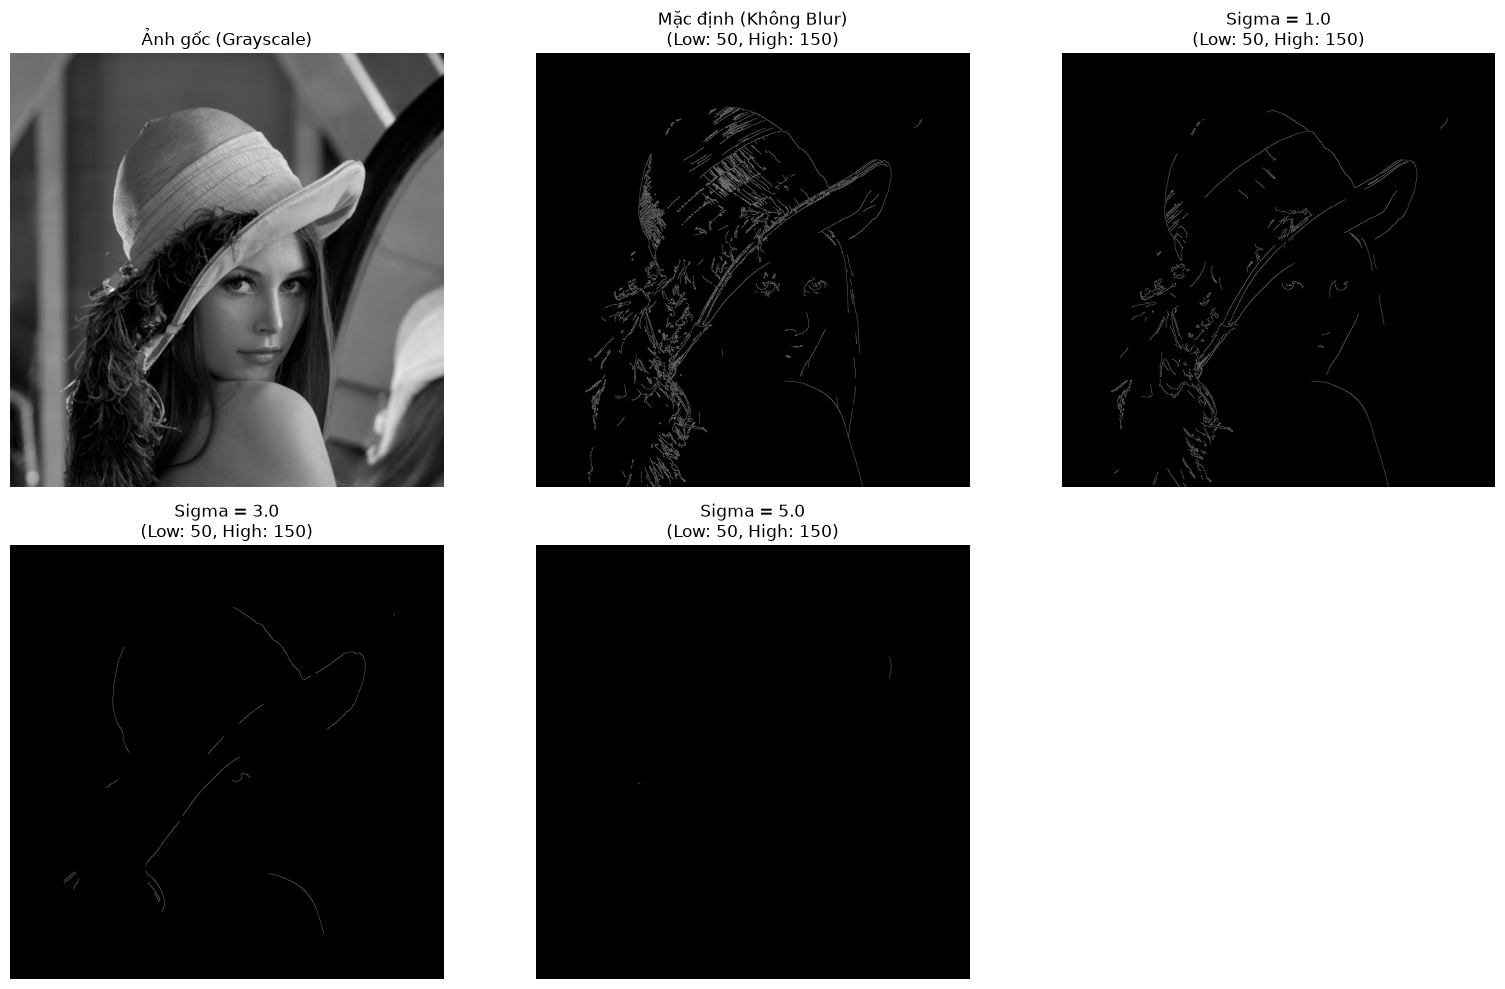

In [2]:
import cv2
import matplotlib.pyplot as plt

img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
low_thresh = 50
high_thresh = 150

#Lưu ý: Kernel size ksize được chọn theo công thức ksize = 6*sigma + 1 (phải là số lẻ)
sigmas = [0, 1.0, 3.0, 5.0]  # 0 nghĩa là mặc định (không Gaussian Blur trước hoặc để Canny tự xử lý)

results = []
titles = []

for sigma in sigmas:
    if sigma == 0:
        # Giá trị mặc định: Không dùng Blur thủ công
        blurred = img_gray.copy()
        title = "Mặc định (Không Blur)"
    else:
        # Tính ksize phù hợp với sigma
        ksize = int(6 * sigma + 1)
        if ksize % 2 == 0: ksize += 1  # Đảm bảo ksize là số lẻ

        blurred = cv2.GaussianBlur(img_gray, (ksize, ksize), sigmaX=sigma)
        title = f"Sigma = {sigma}"

#Thực hiện Canny Edge Detection
    edges = cv2.Canny(blurred, low_thresh, high_thresh)

    results.append(edges)
    titles.append(title)

#Hiển thị kết quả lên cùng 1 hình để so sánh
plt.figure(figsize=(16, 10))

#Hiển thị ảnh gốc
plt.subplot(2, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Ảnh gốc (Grayscale)")
plt.axis('off')

#Hiển thị các trường hợp Sigma
for i in range(len(results)):
    plt.subplot(2, 3, i + 2)
    plt.imshow(results[i], cmap='gray')
    plt.title(f"{titles[i]}\n(Low: {low_thresh}, High: {high_thresh})")
    plt.axis('off')

plt.tight_layout()
plt.show()

Sigma càng lớn thì ảnh càng làm mờ, độ chi tiết giảm đi , dẫn đến số cạnh cũng giảm đi 

# II.3.Áp dụng Canny cho các loại ảnh khác nhau:
- Ảnh có nhiều nhiễu, ảnh có độ tương phản thấp, ảnh có nhiều chi tiết.
- Đánh giá kết quả và rút ra kết luận.

In [29]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [30]:
img = cv2.imread("./datatest/test.jpg")

## 1. Ảnh có nhiều nhiễu, ảnh có độ tương phản thấp, ảnh có nhiều chi tiết.

### Image prep

Noise

(np.float64(-0.5), np.float64(1959.5), np.float64(1959.5), np.float64(-0.5))

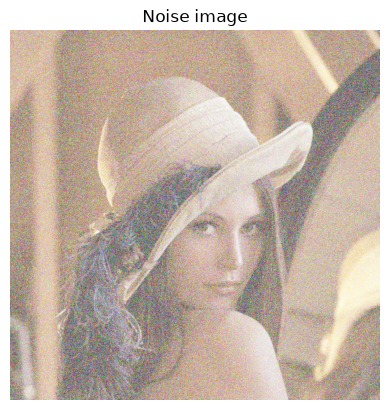

In [59]:
# Tutorial: https://www.youtube.com/watch?v=-d9EB-p9c8o
noise = np.random.normal(0, 25, img.shape).astype(np.uint8)
noiseImg = cv2.cvtColor(cv2.add(img, noise), cv2.COLOR_BGR2RGB)

plt.imshow(noiseImg)
plt.title("Noise image")
plt.axis("off")

Low contrast

(np.float64(-0.5), np.float64(1959.5), np.float64(1959.5), np.float64(-0.5))

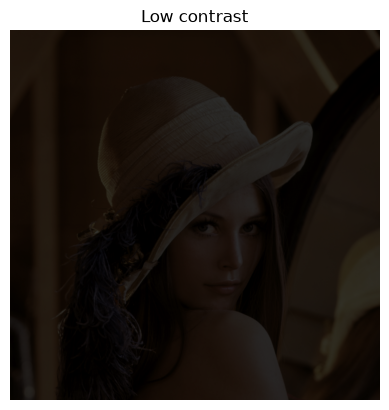

In [60]:
lowConImg = cv2.cvtColor(cv2.convertScaleAbs(
        img,
        alpha=0.2,
        beta=0
    ),

    cv2.COLOR_BGR2RGB
)

plt.imshow(lowConImg)
plt.title("Low contrast")
plt.axis("off")

Detailed

(np.float64(-0.5), np.float64(2047.5), np.float64(1499.5), np.float64(-0.5))

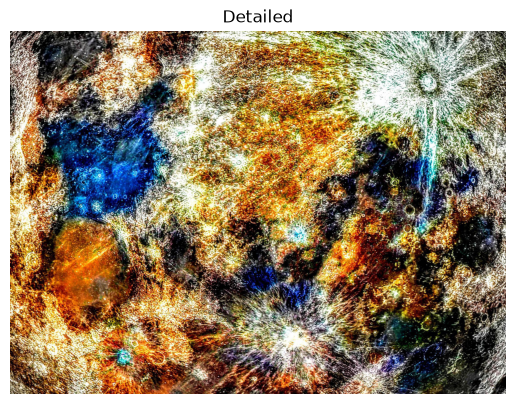

In [62]:
detailedImg = cv2.cvtColor(cv2.imread("./datatest/detailed.jpg"), cv2.COLOR_BGR2RGB)

plt.imshow(detailedImg)
plt.title("Detailed")
plt.axis("off")

### Edge detection

Resource used:

https://docs.opencv.org/4.13.0/da/d22/tutorial_py_canny.html

Threshold

In [52]:
threshold1 = 100
threshold2 = 300

CV2

(np.float64(-0.5), np.float64(2047.5), np.float64(1499.5), np.float64(-0.5))

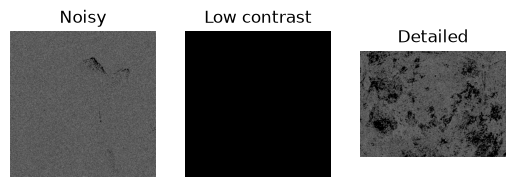

In [87]:
plt.subplot(131),plt.imshow(cv2.Canny(noiseImg, threshold1, threshold2), cmap='gray')
plt.title("Noisy")
plt.axis("off")

plt.subplot(132),plt.imshow(cv2.Canny(lowConImg, threshold1, threshold2), cmap='gray')
plt.title("Low contrast")
plt.axis("off")

plt.subplot(133),plt.imshow(cv2.Canny(detailedImg, threshold1, threshold2), cmap='gray')
plt.title("Detailed")
plt.axis("off")

Có sử dụng AI cho việc đánh giá và kết luận.

1. Ảnh bị nhiễu (Noisy):

Quan sát: Bản đồ cạnh thu được xuất hiện rất nhiều cạnh giả, bị đứt đoạn lan tràn khắp nền ảnh.

Phân tích: Nhiễu Gauss tạo ra các biến thiên độ sáng nhân tạo trên toàn bộ bức ảnh. Vì thuật toán Canny dựa vào độ dốc độ sáng (intensity gradient) để phát hiện ranh giới, nên nó nhầm lẫn các biến thiên nhiễu ở mức điểm ảnh này thành các cạnh thực sự, làm hỏng đáng kể kết quả phát hiện cạnh.



2. Ảnh độ tương phản thấp (Low contrast):

Quan sát: Kết quả đầu ra hoàn toàn là một màu đen (không phát hiện được cạnh nào).

Phân tích: Việc giảm cường độ sáng của ảnh (alpha = 0.2) làm phẳng đáng kể độ dốc độ sáng tại các đường ranh giới. Do độ dốc này giảm xuống dưới ngưỡng dưới của Canny (threshold1), quá trình khử phi cực đại (non-maximum suppression) đã loại bỏ hầu hết các điểm ảnh tiềm năng, dẫn đến thất bại trong việc tìm các cạnh thực.

3. Ảnh nhiều chi tiết / Chi tiết bề mặt phức tạp (Detailed):

Quan sát: Bản đồ cạnh hiển thị một cụm các đường cạnh nhỏ, chằng chịt và vô cùng dày đặc.

Phân tích: Canny phát hiện mọi sự chuyển đổi đột ngột về chi tiết mịn hoặc kết cấu bề mặt. Mặc dù thuật toán trích xuất thành công các cấu trúc tần số cao, nó lại gây ra tình trạng nhiễu rác thông tin nếu mục tiêu chỉ là trích xuất các đường viền cấu trúc chính của đối tượng.

Kết luận cuối cùng

Độ nhạy với nhiễu: Thuật toán Canny tiêu chuẩn rất nhạy cảm với nhiễu cộng tần số cao; việc lọc trước (ví dụ: làm mờ Gauss - Gaussian blur) là bắt buộc để tránh tạo ra quá nhiều cạnh giả.

Sự phụ thuộc vào độ tương phản: Canny phụ thuộc lớn vào độ tương phản rõ ràng giữa các điểm ảnh (độ dốc độ sáng phải đủ mạnh); các hình ảnh có độ tương phản thấp cần các kỹ thuật tiền xử lý (như cân bằng biểu đồ xám - histogram equalization hoặc điều chỉnh lại ngưỡng) để giữ lại các cạnh có thể nhìn thấy.

Gây rối do chi tiết bề mặt: Các bề mặt giàu chi tiết hoặc cấu trúc phức tạp sẽ tạo ra bản đồ cạnh quá dày đặc, đòi hỏi phải tinh chỉnh ngưỡng hoặc làm mịn ảnh để tách biệt các đường biên cấu trúc chủ đạo.

SKLEARN

In [69]:
import skimage 

Convert to grayscale

In [77]:
noiseImgGray = cv2.cvtColor(noiseImg, cv2.COLOR_RGB2GRAY)
lowConImgGray = cv2.cvtColor(lowConImg, cv2.COLOR_RGB2GRAY)
detailedImgGray = cv2.cvtColor(detailedImg, cv2.COLOR_RGB2GRAY)


SKSKSKSKSKSKS

/tmp/ipykernel_82177/3001827640.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(skimage.feature.canny(noiseImgGray))


(np.float64(-0.5), np.float64(1959.5), np.float64(1959.5), np.float64(-0.5))

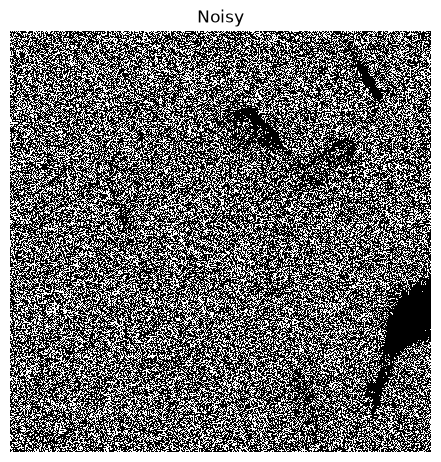

In [92]:
skimage.io.imshow(skimage.feature.canny(noiseImgGray))

plt.title("Noisy")
plt.axis("off")


1. Ảnh bị nhiễu:

Quan sát: Ảnh bị bao phủ hoàn toàn bởi các đốm trắng/cạnh giả dày đặc, gần như che lấp hoàn toàn cấu trúc hình ảnh gốc (chỉ còn thấy lờ mờ một số nét chính ở vùng tối).

Phân tích: Hàm Canny của skimage nếu không được thiết lập tham số làm mờ sigma đủ lớn sẽ coi các hạt nhiễu Gauss là các biến thiên độ sáng mạnh. Do đó, thuật toán nhận diện nhiễu thành hàng triệu cạnh nhỏ, gây nên hiện tượng nhiễu rác toàn màn hình.

/tmp/ipykernel_82177/2123753985.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(skimage.feature.canny(lowConImgGray))


(np.float64(-0.5), np.float64(1959.5), np.float64(1959.5), np.float64(-0.5))

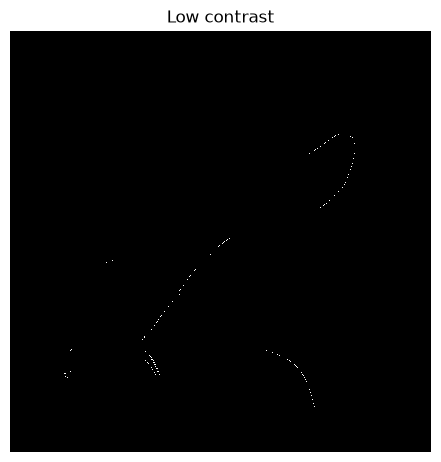

In [91]:
skimage.io.imshow(skimage.feature.canny(lowConImgGray))

plt.title("Low contrast")
plt.axis("off")


2. Ảnh độ tương phản thấp (Low contrast):

Quan sát: Nhận diện được một số đường nét đứt đoạn, mỏng và thưa thớt của đối tượng (vành mũ, đường nét khuôn mặt, vai).

Phân tích: Khác với OpenCV (trả về màn hình đen hoàn toàn khi dùng ngưỡng cố định), skimage.feature.canny có cơ chế tự động ước lượng ngưỡng dựa trên trung vị/độ lệch của độ dốc ảnh nếu không truyền ngưỡng thủ công. Tuy nhiên, do độ tương phản gốc quá yếu (alpha = 0.2), các cạnh bị đứt đoạn nghiêm trọng và không thể tạo thành đường biên liên tục.

/tmp/ipykernel_82177/3502477520.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(skimage.feature.canny(detailedImgGray))


(np.float64(-0.5), np.float64(2047.5), np.float64(1499.5), np.float64(-0.5))

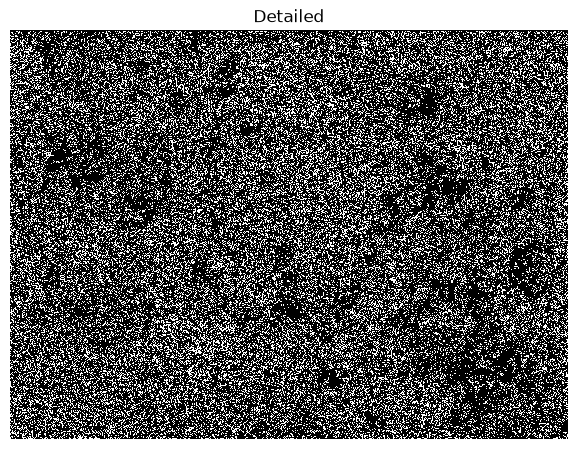

In [93]:
skimage.io.imshow(skimage.feature.canny(detailedImgGray))

plt.title("Detailed")
plt.axis("off")

3. Ảnh nhiều chi tiết / Chi tiết bề mặt phức tạp (Detailed):

Quan sát: Xuất hiện một mật độ cực kỳ dày đặc các điểm cạnh trắng lấp đầy toàn bộ bức ảnh, không thể phân biệt được đâu là vật thể chính hay nền.

Phân tích: Bề mặt ảnh có quá nhiều chi tiết tần số cao và kết cấu phức tạp. Thuật toán Canny của skimage đã bắt trọn từng biến thiên nhỏ nhất của bề mặt, dẫn đến tình trạng quá tải thông tin (information overload) trên bản đồ cạnh.